In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (4, 3)

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

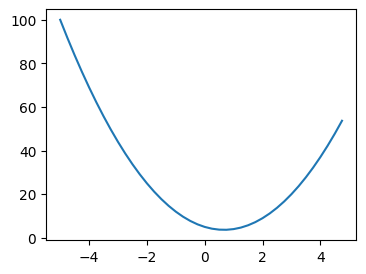

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.show()

In [5]:
### Differentiating
h = 0.000000001 #nudge function of x by a little
x = 3 # to see the slope of the function at point 3 of x axis
(f(x+h) - (f(x)))/h ## divide by h, to see slope rise/run or changes in y/ changes in x

14.000001158365194

In [6]:
h = 0.000000001 
x = 2/3
(f(x+h) - (f(x)))/h 

0.0

$\text{At point $\dfrac{2}{3}$ the derivative is 0, which means the slope is zero}$


In [7]:
a = 2
b = -3
c = 10
d= a*b + c
d

4

In [8]:
a = 2
b = -3
c = 10
d= a*b + c
d

4

In [9]:
h = 0.0001

#inputs
a = 2
b = -3
c = 10

d1 = a*b + c
a+=h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("slope" , f"{(d2-d1)/h:.2f}") 

d1 4
d2 3.999699999999999
slope -3.00


So increasing "a" will mean we will be going in the negative direction by slope of -3. 


and increasing "b" will mean we are going in the positive direction of slope 2. 


and "c" will just have a slope of 1. 

### Creating Class Value 
it should hold scaler values, plus implement all of their operations

In [10]:
class Value: 
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
    def __repr__(self): ## dunder function for representation
        return f"Value(data={self.data})"
    def __add__(self, other): 
        return Value(self.data + other.data, (self, other), '+')
    def __mul__(self, other): 
        return Value(self.data * other.data, (self, other), '*')

In [11]:
a = Value(2)
b = Value(-3)

a,b

(Value(data=2), Value(data=-3))

In [12]:
a.__mul__(b) or a*b

Value(data=-6)

In [13]:
c = Value(10)
a.__mul__(b).__add__(c)

Value(data=4)

In [14]:
d = a*b + c
d._op

'+'

In [15]:
!pip install -Uq graphviz

In [16]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ data %.4f }" % (n.data,),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this op node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


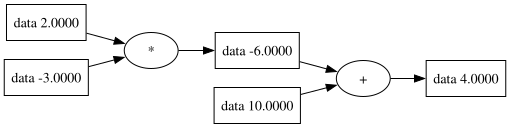

In [17]:
draw_dot(d)

### Experiments to figure it the tracing algorithm

In [19]:
def trace(root):
    nodes = set()
    edges = set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for parent in v._prev:
                edges.add((parent, v))
                build(parent)

    build(root)
    return nodes, edges

"""
so we build with v, v is ofcourse a node, because it is a number
if v is not then add it. 

then next, for their parents, add them as edges. 
"""

print()

In [20]:
aa = Value(1)
bb = Value(2)


In [21]:
cc = aa + bb

In [100]:
if cc._op: 
    print('true')

true


In [23]:
cc._op

In [25]:
nodes, edges = set(), set()

nodes, edges

(set(), set())

In [29]:
if cc not in nodes: 
    nodes.add(cc)

In [30]:
nodes

{Value(data=3)}

In [33]:
for parent in cc._prev: 
    edges.add((parent, cc))

In [34]:
edges

{(Value(data=1), Value(data=3)), (Value(data=2), Value(data=3))}

In [38]:
def trace(root_node): 
    nodes, edges = set(), set()
    
    def build(node): 
        if node not in nodes: 
            nodes.add(node)
            for parent in node._prev: 
                edges.add((parent, node))
                build(parent)
                
    build(root_node)
    return nodes, edges

    def draw_values_with_edges(nodes, edges): 
        dot = Digraph()
        for n in nodes: 
            uid = str(id(n))
            dot.node(uid, f"data = {n.data}")
        # Now we are looping over the edges, using the str id, we can create edge for each node
        for v1, v2 in edges: 
            dot.edge(str(id(v1)), str(id(v2)))
        
        return dot



In [40]:
dd = cc + Value(6)

In [58]:
nodes, edges = trace(cc)

nodes, edges

({Value(data=1), Value(data=2), Value(data=3)},
 {(Value(data=1), Value(data=3)), (Value(data=2), Value(data=3))})

In [88]:
for v1, v2 in edges: 
    print(v1, v2)

Value(data=2) Value(data=3)
Value(data=1) Value(data=3)


In [128]:
def draw_values_with_edges(expression): 
        nodes, edges = trace(expression)
        

        dot = Digraph(graph_attr={'rankdir': 'LR'})
        for n in nodes: 
            uid = str(id(n))
            dot.node(uid, f"data = {n.data}", shape='record')
            
            if n._op: # if it has an operater, then create a node operator and connected to the node
                # if 3, were the result of 1 plus 2, then make + --> 3. 
                opid = uid + str(id(n._op))
                dot.node(opid, n._op)
                dot.edge(opid, uid)
            
            
        # Now we are looping over the edges, using the str id, we can create edge for each node
        for v1, v2 in edges: 
            dot.edge(str(id(v1)), str(id(v2)) + str(id(v2._op))) #connect each childeren to the operator.
            # and since we are looping in edges only, they are guranteed to have operators. 
        
        return dot


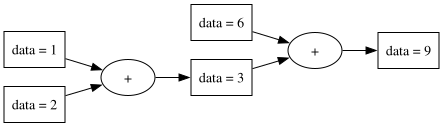

In [129]:
draw_values_with_edges(dd)

In [121]:
str(id(aa))

'4780742528'

In [120]:
str(id(aa)) + str(id(aa._op))

'47807425284309499952'

In [122]:
ddot = Digraph()

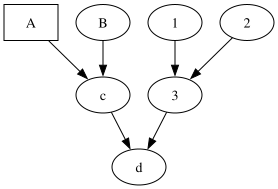

In [123]:
ddot.node('A', 'A', shape='record')
ddot.node('B', 'B')
ddot.edge('A', 'c')
ddot.edge('B', 'c')


ddot.node('1', '1')
ddot.node('2', '2')
ddot.edge('1', '3')
ddot.edge('2', '3')

ddot.edge('3', 'd')
ddot.edge('c', 'd')

ddot

### Continue